In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


c:\Users\chand\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import pandas as pd
import numpy as np
import joblib
from sklearn.preprocessing import StandardScaler

# Load dataset fresh
df = pd.read_csv('../data/creditcard.csv')

# Create NEW scaler and fit on Amount and Time
scaler_amount = StandardScaler()
scaler_time = StandardScaler()

df['scaled_amount'] = scaler_amount.fit_transform(df[['Amount']])
df['scaled_time'] = scaler_time.fit_transform(df[['Time']])

# Drop original columns
df.drop(['Amount', 'Time'], axis=1, inplace=True)

# Features and target
X = df.drop('Class', axis=1)
y = df['Class']

# Load best model (XGBoost)
model = joblib.load('../models/best_model.pkl')

print("✅ Model and data loaded successfully!")
print("Model type:", type(model).__name__)
print("X shape:", X.shape)

✅ Model and data loaded successfully!
Model type: XGBClassifier
X shape: (284807, 30)


In [3]:
# Use a sample of 500 rows for speed
X_sample = X.sample(500, random_state=42)

# Fix: Use booster directly
booster = model.get_booster()
explainer = shap.TreeExplainer(booster)
shap_values = explainer.shap_values(X_sample)

print("✅ SHAP values calculated!")
print("Shape:", shap_values.shape)

✅ SHAP values calculated!
Shape: (500, 30)


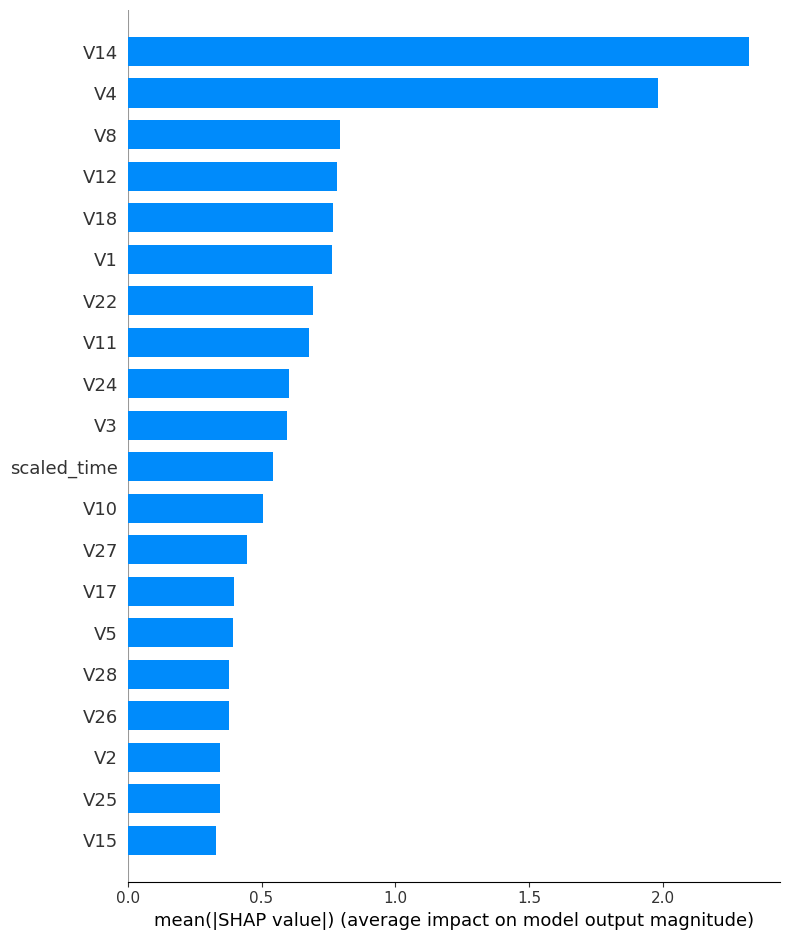

<Figure size 640x480 with 0 Axes>

In [4]:
plt.figure()
shap.summary_plot(shap_values, X_sample, plot_type="bar",title="Top Features Contributing to Fraud Detection")
plt.tight_layout()
plt.show()

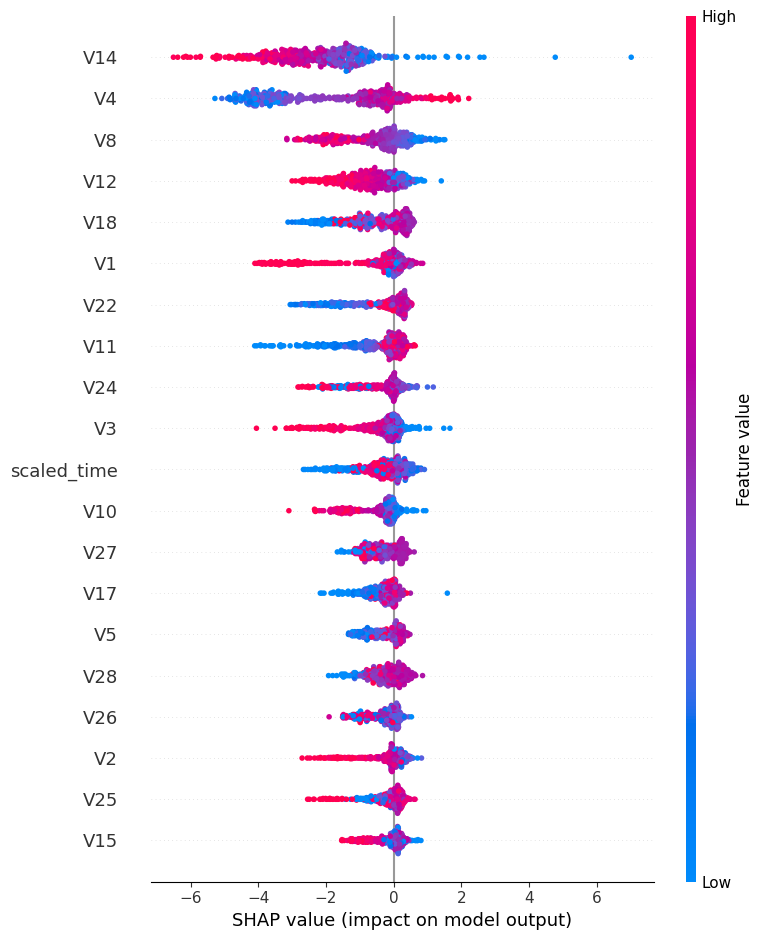

<Figure size 640x480 with 0 Axes>

In [5]:
plt.figure()
shap.summary_plot(shap_values, X_sample)
plt.tight_layout()
plt.show()

Explaining this fraud transaction:
           V1        V2        V3        V4        V5        V6        V7  \
541 -2.312227  1.951992 -1.609851  3.997906 -0.522188 -1.426545 -2.537387   

           V8        V9       V10  ...       V21       V22       V23  \
541  1.391657 -2.770089 -2.772272  ...  0.517232 -0.035049 -0.465211   

          V24       V25      V26       V27       V28  scaled_amount  \
541  0.320198  0.044519  0.17784  0.261145 -0.143276      -0.353229   

     scaled_time  
541    -1.988034  

[1 rows x 30 columns]


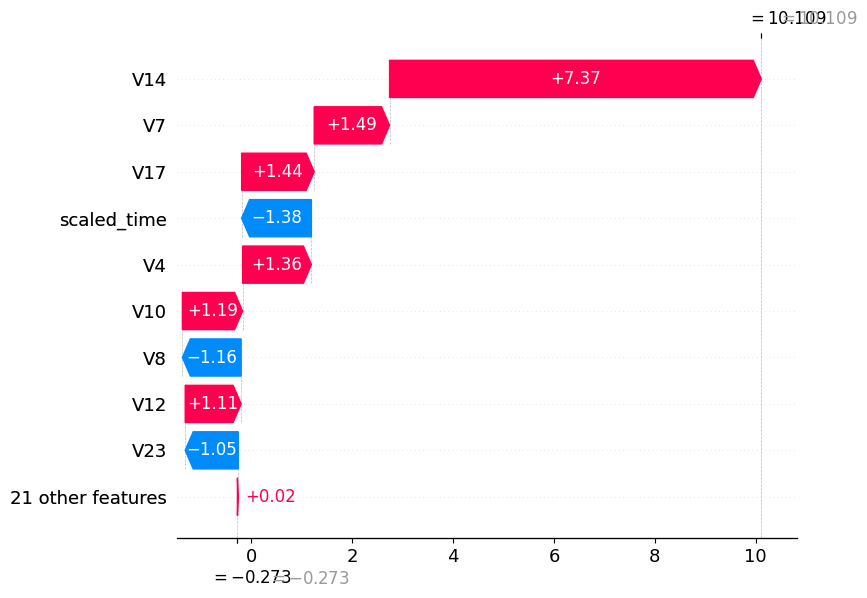

In [6]:
# Pick one fraud transaction and explain it
fraud_indices = df[y == 1].index
single_fraud = X.loc[fraud_indices[0]:fraud_indices[0]]

# SHAP values for this single transaction
single_shap = explainer.shap_values(single_fraud)

print("Explaining this fraud transaction:")
print(single_fraud)

# Waterfall plot
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value,
    single_shap[0],
    feature_names=X.columns.tolist()
)
plt.show()

Top 10 Most Important Features for Fraud Detection:
Feature  SHAP Importance
    V14         2.319946
     V4         1.981344
     V8         0.793635
    V12         0.780563
    V18         0.767516
     V1         0.763723
    V22         0.693118
    V11         0.678428
    V24         0.604113
     V3         0.596497


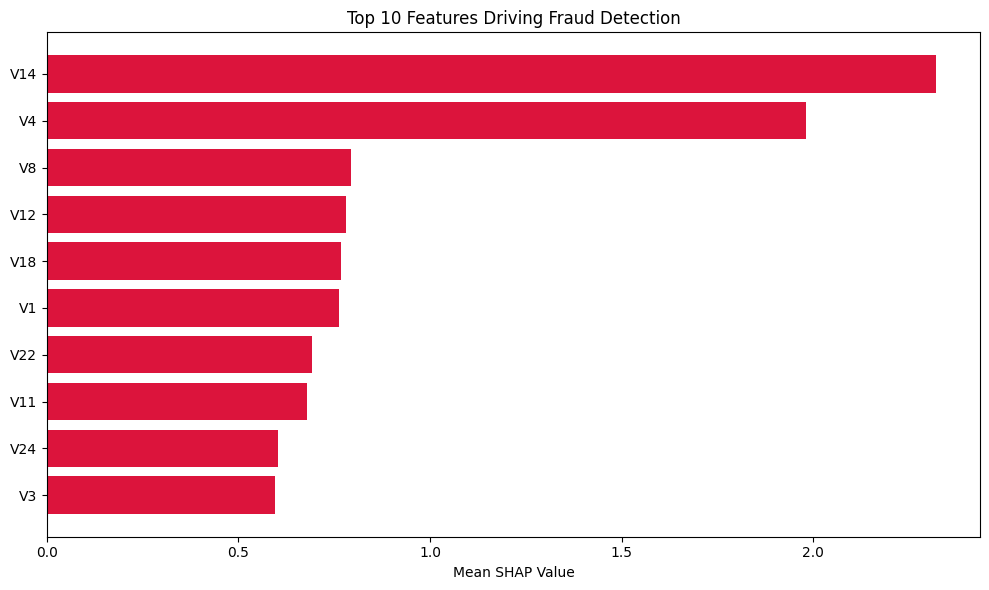

In [7]:
# Get mean absolute SHAP values
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'SHAP Importance': np.abs(shap_values).mean(axis=0)
}).sort_values('SHAP Importance', ascending=False)

print("Top 10 Most Important Features for Fraud Detection:")
print(feature_importance.head(10).to_string(index=False))

# Plot
plt.figure(figsize=(10, 6))
top10 = feature_importance.head(10)
plt.barh(top10['Feature'], top10['SHAP Importance'], color='crimson')
plt.xlabel('Mean SHAP Value')
plt.title('Top 10 Features Driving Fraud Detection')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()